In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

In [2]:
import numpy as np
import pandas as pd

# Load
raw = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")
raw = raw.dropna(axis=1, how="all").replace(-200, np.nan)
raw["datetime"] = pd.to_datetime(
    raw["Date"] + " " + raw["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S", errors="coerce"
)
raw = raw.dropna(subset=["datetime"]).drop_duplicates().reset_index(drop=True)

# Features and Target
FEATURES = [
    "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)",
    "NOx(GT)", "PT08.S3(NOx)", "NO2(GT)",
    "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"
]
TARGET = "CO(GT)"

data = raw[FEATURES + [TARGET]].dropna(subset=[TARGET]).reset_index(drop=True)

# Impute missing feature values with median
for col in FEATURES:
    data[col] = data[col].fillna(data[col].median())

X = data[FEATURES]
y = data[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())


X shape: (7674, 11)
y shape: (7674,)


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [3]:
print("Shape:", data.shape)
print("\n--- Missing Values ---")
missing = data.isna().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

print("\n--- Duplicate Rows ---")
print("Duplicates:", data.duplicated().sum())

print("\n--- Data Types ---")
print(data.dtypes)

print("\n--- Basic Statistics ---")
display(data.describe())

print("\n--- Negative Values (invalid for pollutants) ---")
for col in FEATURES:
    neg = (data[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg} negative values")
print("Done")


Shape: (7674, 12)

--- Missing Values ---
No missing values

--- Duplicate Rows ---
Duplicates: 1

--- Data Types ---
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
CO(GT)           float64
dtype: object

--- Basic Statistics ---


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
count,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000
mean,1109.050691,10.199375,945.985536,251.691165,825.547433,114.551082,1444.849361,1041.211754,17.732995,49.070394,0.988174,2.152750
std,214.048885,7.288206,259.763178,210.022201,251.152318,46.930717,342.727887,396.900917,8.671809,17.072230,0.391242,1.453252
min,647.000000,0.200000,387.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.100000
25%,953.000000,4.800000,752.000000,107.000000,657.000000,82.000000,1215.250000,759.000000,11.500000,36.200000,0.714375,1.100000
50%,1075.000000,8.500000,919.000000,188.000000,795.000000,110.000000,1447.000000,990.000000,16.900000,49.300000,0.959700,1.800000
75%,1235.000000,14.000000,1116.750000,326.000000,949.000000,141.000000,1659.000000,1287.000000,23.500000,61.800000,1.235200,2.900000
max,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.180600,11.900000



--- Negative Values (invalid for pollutants) ---
  T: 12 negative values
Done


--- Class Distribution ---
CO(GT)
Low       4346
Medium    2516
High       812
Name: count, dtype: int64

Percentage:
CO(GT)
Low       56.63
Medium    32.79
High      10.58
Name: count, dtype: float64


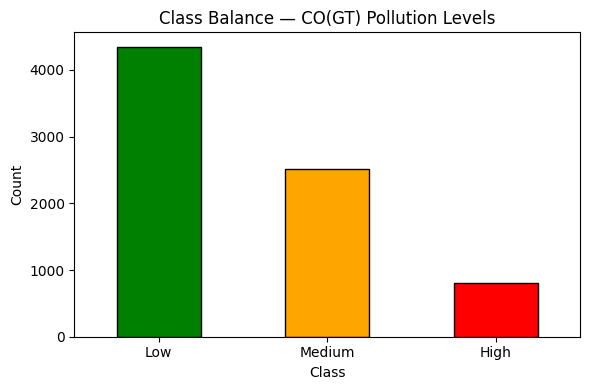

In [4]:
import matplotlib.pyplot as plt

# Bin CO(GT) into 3 classes
bins   = [0, 2, 4, np.inf]
labels = ["Low", "Medium", "High"]

y_class = pd.cut(y, bins=bins, labels=labels)

print("--- Class Distribution ---")
counts = y_class.value_counts().sort_index()
print(counts)
print("\nPercentage:")
print((counts / len(y_class) * 100).round(2))

# Plot
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["green", "orange", "red"], edgecolor="black")
plt.title("Class Balance — CO(GT) Pollution Levels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y_test.value_counts().sort_index())


Train size: (6139, 11)
Test size : (1535, 11)

Train class distribution:
CO(GT)
Low       3477
Medium    2013
High       649
Name: count, dtype: int64

Test class distribution:
CO(GT)
Low       869
Medium    503
High      163
Name: count, dtype: int64


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

print("Tree trained successfully.")
print("Depth :", pipeline["tree"].get_depth())
print("Leaves:", pipeline["tree"].get_n_leaves())


Tree trained successfully.
Depth : 3
Leaves: 8


In [7]:
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)

# Show first 10 predictions
results = pd.DataFrame({
    "Actual"      : y_test.values,
    "Predicted"   : y_pred,
    "P(Low)"      : y_pred_proba[:, 0].round(3),
    "P(Medium)"   : y_pred_proba[:, 1].round(3),
    "P(High)"     : y_pred_proba[:, 2].round(3),
})

print(results.head(10))


   Actual Predicted  P(Low)  P(Medium)  P(High)
0  Medium    Medium   0.108      0.079    0.813
1     Low       Low   0.000      0.978    0.022
2     Low       Low   0.000      0.978    0.022
3     Low       Low   0.000      0.978    0.022
4     Low       Low   0.000      0.978    0.022
5  Medium       Low   0.000      0.978    0.022
6     Low       Low   0.000      0.978    0.022
7     Low       Low   0.000      0.978    0.022
8    High    Medium   0.108      0.079    0.813
9  Medium    Medium   0.108      0.079    0.813


In [8]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.dummy import DummyClassifier

# --- Decision Tree performance ---
acc_tree = accuracy_score(y_test, y_pred)
print("=== Decision Tree ===")
print(f"Accuracy: {acc_tree:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Low", "Medium", "High"],
                            zero_division=0))

# --- Majority baseline ---
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
acc_dummy = accuracy_score(y_test, y_pred_dummy)

print("=== Majority Baseline ===")
print(f"Accuracy: {acc_dummy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dummy,
                            target_names=["Low", "Medium", "High"],
                            zero_division=0))

# --- Comparison ---
print("=== Comparison ===")
print(f"Tree accuracy   : {acc_tree:.4f}")
print(f"Baseline accuracy: {acc_dummy:.4f}")
print(f"Improvement      : {acc_tree - acc_dummy:+.4f}")


=== Decision Tree ===
Accuracy: 0.8606

Classification Report:
              precision    recall  f1-score   support

         Low       0.85      0.69      0.76       163
      Medium       0.92      0.91      0.92       869
        High       0.77      0.82      0.79       503

    accuracy                           0.86      1535
   macro avg       0.85      0.81      0.82      1535
weighted avg       0.86      0.86      0.86      1535

=== Majority Baseline ===
Accuracy: 0.5661

Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       163
      Medium       0.57      1.00      0.72       869
        High       0.00      0.00      0.00       503

    accuracy                           0.57      1535
   macro avg       0.19      0.33      0.24      1535
weighted avg       0.32      0.57      0.41      1535

=== Comparison ===
Tree accuracy   : 0.8606
Baseline accuracy: 0.5661
Improvement      : +0.2945


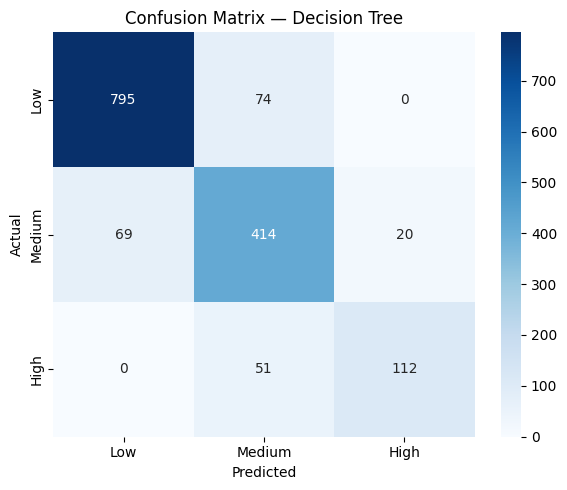

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()


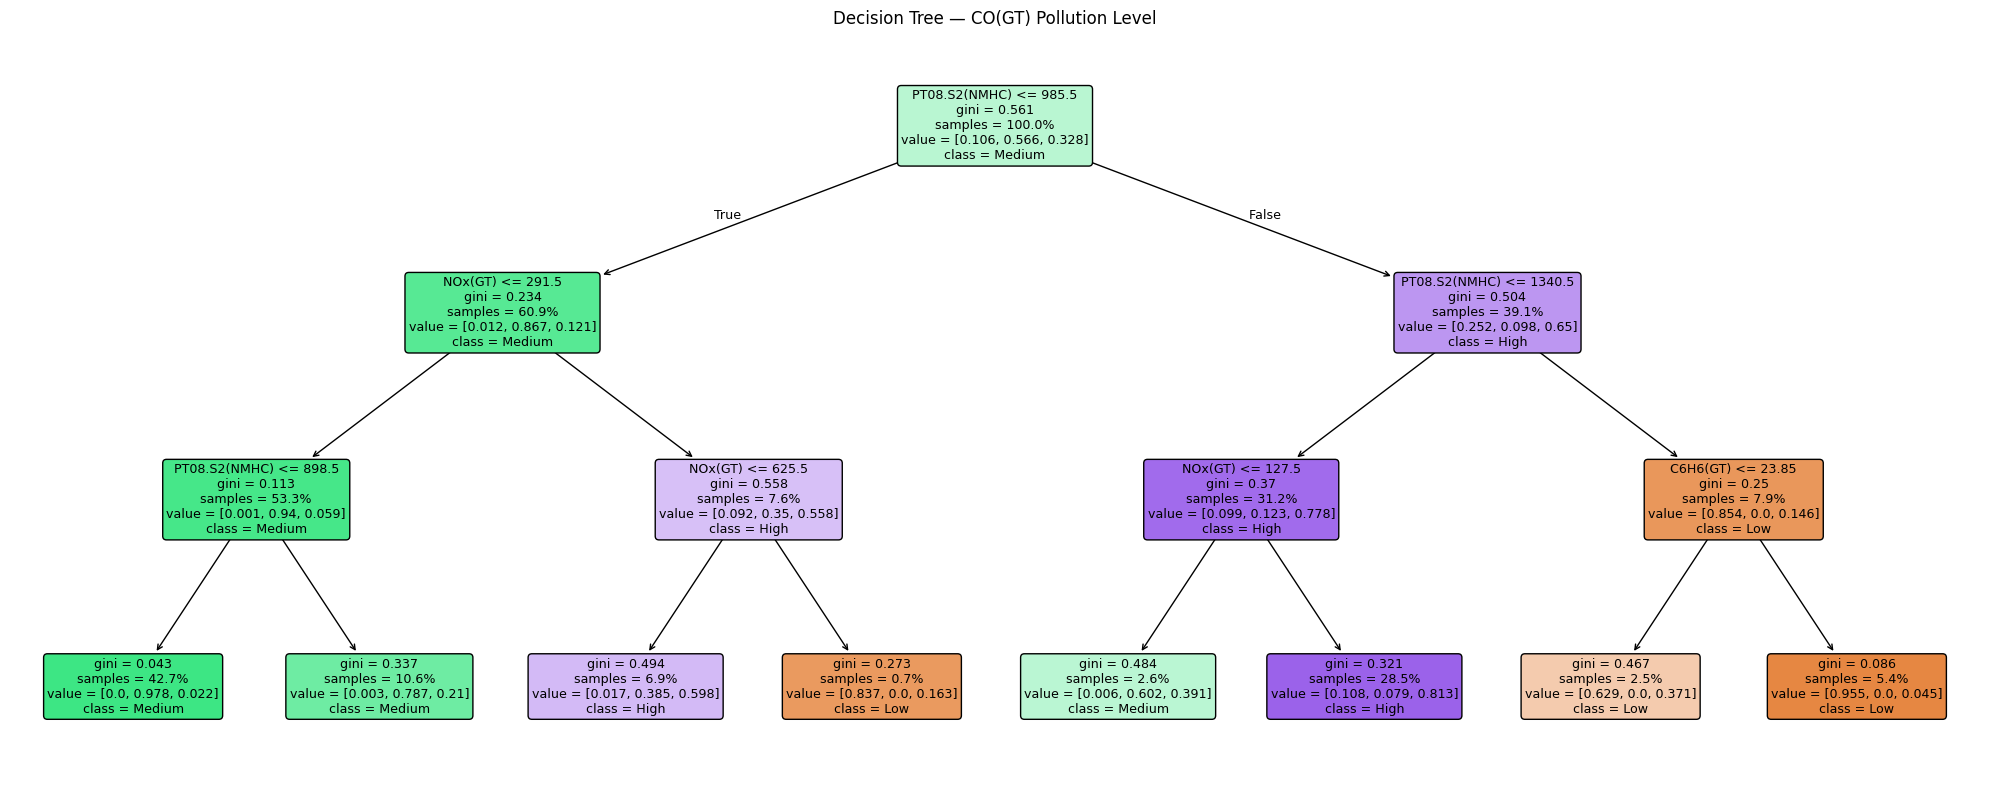

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    pipeline["tree"],
    feature_names=FEATURES,
    class_names=["Low", "Medium", "High"],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=True,
    max_depth=3
)
plt.title("Decision Tree — CO(GT) Pollution Level")
plt.tight_layout()
plt.show()



In [12]:
from sklearn.tree import export_text

class_names = ["Low", "Medium", "High"]

rules = export_text(
    pipeline["tree"],
    feature_names=FEATURES,
    decimals=3,
    show_weights=True
)

print("===== Decision Rules =====\n")
print(rules)


===== Decision Rules =====

|--- PT08.S2(NMHC) <= 985.500
|   |--- NOx(GT) <= 291.500
|   |   |--- PT08.S2(NMHC) <= 898.500
|   |   |   |--- weights: [0.000, 2566.000, 57.000] class: Low
|   |   |--- PT08.S2(NMHC) >  898.500
|   |   |   |--- weights: [2.000, 513.000, 137.000] class: Low
|   |--- NOx(GT) >  291.500
|   |   |--- NOx(GT) <= 625.500
|   |   |   |--- weights: [7.000, 163.000, 253.000] class: Medium
|   |   |--- NOx(GT) >  625.500
|   |   |   |--- weights: [36.000, 0.000, 7.000] class: High
|--- PT08.S2(NMHC) >  985.500
|   |--- PT08.S2(NMHC) <= 1340.500
|   |   |--- NOx(GT) <= 127.500
|   |   |   |--- weights: [1.000, 97.000, 63.000] class: Low
|   |   |--- NOx(GT) >  127.500
|   |   |   |--- weights: [189.000, 138.000, 1425.000] class: Medium
|   |--- PT08.S2(NMHC) >  1340.500
|   |   |--- C6H6(GT) <= 23.850
|   |   |   |--- weights: [95.000, 0.000, 56.000] class: High
|   |   |--- C6H6(GT) >  23.850
|   |   |   |--- weights: [319.000, 0.000, 15.000] class: High



=== Feature Importances ===
      Feature  Importance
PT08.S2(NMHC)    0.824766
      NOx(GT)    0.164960
     C6H6(GT)    0.010274
  PT08.S1(CO)    0.000000
 PT08.S3(NOx)    0.000000
      NO2(GT)    0.000000
 PT08.S4(NO2)    0.000000
  PT08.S5(O3)    0.000000
            T    0.000000
           RH    0.000000
           AH    0.000000

Sum of importances: 1.0000


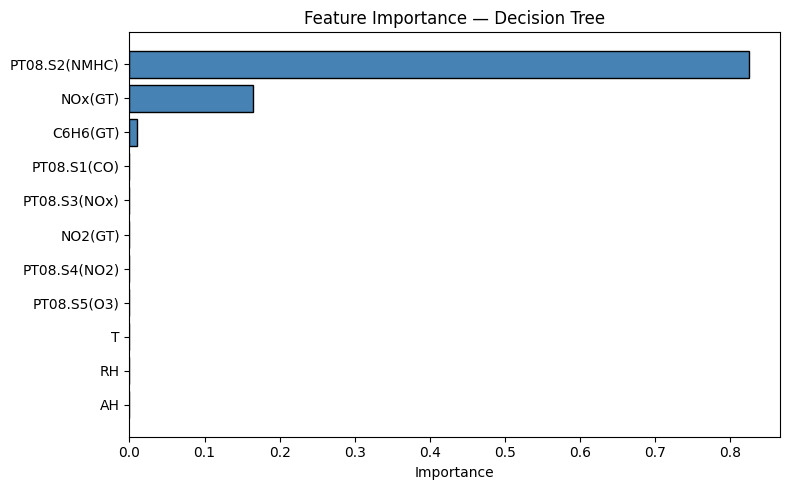

In [13]:
importance = pipeline["tree"].feature_importances_

imp_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": importance
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("=== Feature Importances ===")
print(imp_df.to_string(index=False))
print(f"\nSum of importances: {importance.sum():.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
         color="steelblue", edgecolor="black")
plt.xlabel("Importance")
plt.title("Feature Importance — Decision Tree")
plt.tight_layout()
plt.show()


In [14]:
# --- Unrestricted tree (no depth limit) ---
full_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(random_state=42))
])
full_pipeline.fit(X_train, y_train)

# --- Scores ---
train_acc_restricted = accuracy_score(y_train, pipeline.predict(X_train))
test_acc_restricted  = accuracy_score(y_test,  pipeline.predict(X_test))

train_acc_full = accuracy_score(y_train, full_pipeline.predict(X_train))
test_acc_full  = accuracy_score(y_test,  full_pipeline.predict(X_test))

# --- Complexity ---
print("=== Restricted Tree (max_depth=3) ===")
print(f"Depth        : {pipeline['tree'].get_depth()}")
print(f"Leaves       : {pipeline['tree'].get_n_leaves()}")
print(f"Train accuracy: {train_acc_restricted:.4f}")
print(f"Test  accuracy: {test_acc_restricted:.4f}")

print("\n=== Unrestricted Tree ===")
print(f"Depth        : {full_pipeline['tree'].get_depth()}")
print(f"Leaves       : {full_pipeline['tree'].get_n_leaves()}")
print(f"Train accuracy: {train_acc_full:.4f}")
print(f"Test  accuracy: {test_acc_full:.4f}")

print("\n=== Overfitting Gap (Unrestricted) ===")
print(f"Train - Test  : {train_acc_full - test_acc_full:+.4f}")


=== Restricted Tree (max_depth=3) ===
Depth        : 3
Leaves       : 8
Train accuracy: 0.8640
Test  accuracy: 0.8606

=== Unrestricted Tree ===
Depth        : 24
Leaves       : 544
Train accuracy: 0.9993
Test  accuracy: 0.8443

=== Overfitting Gap (Unrestricted) ===
Train - Test  : +0.1550


In [17]:
# --- New sample (hypothetical, uses original dataset units) ---
new_record = pd.DataFrame([[
    1200,   # PT08.S1(CO)
    8.5,    # C6H6(GT)
    950,    # PT08.S2(NMHC)
    120.0,  # NOx(GT)
    1100,   # PT08.S3(NOx)
    100.0,  # NO2(GT)
    1500,   # PT08.S4(NO2)
    1050,   # PT08.S5(O3)
    15.0,   # T
    55.0,   # RH
    0.75    # AH
]], columns=FEATURES)

# --- Prediction ---
pred_class = pipeline.predict(new_record)[0]
pred_proba = pipeline.predict_proba(new_record)[0]
class_names = ["Low", "Medium", "High"]

print("=== Prediction ===")
print(f"Predicted class : {pred_class}")
print(f"P(Low)={pred_proba[0]:.3f}  P(Medium)={pred_proba[1]:.3f}  P(High)={pred_proba[2]:.3f}")

# --- Trace the path ---
tree      = pipeline["tree"]
imputer   = pipeline["imputer"]
X_new_imp = imputer.transform(new_record)

node_indicator = tree.decision_path(X_new_imp)  # method on the estimator
node_ids       = node_indicator.indices

threshold  = tree.tree_.threshold
feature    = tree.tree_.feature
left_child = tree.tree_.children_left

print("\n=== Decision Path ===")
for node in node_ids:
    if left_child[node] == -1:          # leaf
        print(f"  Node {node} → LEAF → Predicted: {pred_class}")
    else:
        feat  = FEATURES[feature[node]]
        thr   = threshold[node]
        val   = X_new_imp[0][feature[node]]
        direc = "<= (go left)" if val <= thr else "> (go right)"
        print(f"  Node {node}: {feat} = {val:.3f} {direc} {thr:.3f}")


=== Prediction ===
Predicted class : Low
P(Low)=0.003  P(Medium)=0.787  P(High)=0.210

=== Decision Path ===
  Node 0: PT08.S2(NMHC) = 950.000 <= (go left) 985.500
  Node 1: NOx(GT) = 120.000 <= (go left) 291.500
  Node 2: PT08.S2(NMHC) = 950.000 > (go right) 898.500
  Node 4 → LEAF → Predicted: Low
